# FAISS 의미 검색 평가 노트북

AI 자연어 질의(`/query/ai`)의 임베딩 검색 품질과 **임계값**을 수치로 본다. 앱 런타임이 아니라 분석용이다.

- 데이터: dev DB(`backend/data/navigation.db`, `thehyundai-seoul`)
- 모델: `jhgan/ko-sroberta-multitask` (768d), 코사인 = L2정규화 + IndexFlatIP
- 설계·임계값 근거: [docs/backend/native/FAISS.md](../../docs/backend/native/FAISS.md) (11-1절)

> 실행: backend/.venv 커널로 `Run All`. 모델이 캐시에 없으면 첫 셀에서 ~400MB 다운로드.

In [1]:
# 셋업 — backend를 sys.path에 넣고 모델·인덱스를 로드한다.
import sys, pathlib, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

here = pathlib.Path.cwd()
backend = next(p for p in [here, *here.parents] if (p / 'app' / 'core' / 'database.py').exists())
sys.path.insert(0, str(backend))

# 한글 라벨이 깨지지 않게(Windows). 다른 OS면 가용 폰트로 교체.
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

from app.core.database import SessionLocal
from app.repositories import query_semantic
from app.repositories.query_search import _load_stores

BUILDING = 'thehyundai-seoul'
session = SessionLocal()
model = query_semantic._get_model()
index, store_ids = query_semantic._get_index(session, BUILDING)
rows = {s.id: (s, f) for s, f in _load_stores(session, BUILDING)}
TH = query_semantic.SIMILARITY_THRESHOLD
print(f'인덱스 {index.ntotal}개 벡터, dim={index.d}, 임계값={TH}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

인덱스 1531개 벡터, dim=768, 임계값=0.5


In [2]:
# 검색 헬퍼 — 질의 → 상위 k건 (score, name, category, subcategory, floor).
def search(query, k=3):
    qv = np.ascontiguousarray(
        model.encode([query], normalize_embeddings=True, convert_to_numpy=True), dtype='float32'
    )
    scores, positions = index.search(qv, k)
    out = []
    for score, pos in zip(scores[0], positions[0]):
        s, f = rows[store_ids[pos]]
        out.append((float(score), s.name, s.category, s.subcategory, f.name))
    return out

def relevant(row, expected):
    # 상위1건이 기대 카테고리/키워드에 걸리면 관련으로 본다(정규식 대안).
    _score, name, cat, sub, _fl = row
    blob = ' '.join(x or '' for x in (name, cat, sub))
    return bool(re.search(expected, blob))

## 1. 질의 세트

긍정(자연어→기대 카테고리)과 부정(무의미→no_match여야 함)으로 나눈다. `expected`는 상위1건이 걸려야 할 키워드(정규식).

In [3]:
POSITIVES = [
    ('음식',   '밥 먹을 곳',        'restaurant|식음료|취식'),
    ('음식',   '배고픈데 뭐 먹지',  'restaurant|식음료'),
    ('분식',   '김밥 같은 분식',    'restaurant|김밥|분식'),
    ('카페',   '커피 마시고 싶어',  '커피|카페|restaurant'),
    ('디저트', '디저트랑 케이크',   '베이커리|케이크|restaurant'),
    ('뷰티',   '화장품 사려고',     '화장품'),
    ('뷰티',   '향수 보고 싶어',    '화장품|향수'),
    ('뷰티',   '립스틱 어디',       '화장품'),
    ('키즈',   '애들 옷',           '키즈|아동|유아'),
    ('키즈',   '아기 장난감',       '토이|완구|키즈'),
    ('슈즈',   '신발 파는 데',      '슈즈'),
    ('슈즈',   '운동화 사고 싶다',  '슈즈|스포츠'),
    ('패션',   '가방 보러 왔어',    '잡화|액세서리|명품|가방'),
    ('패션',   '남자 정장',         '컨템포러리|정장|수트'),
    ('명품',   '명품 매장',         '명품'),
    ('스포츠', '등산복 아웃도어',   '아웃도어|스포츠'),
    ('리빙',   '그릇이나 주방용품', '리빙|주방'),
    ('문구',   '예쁜 문구류',       '문구|팬시'),
    ('시설',   '화장실 급해',       'restroom|화장실'),
    ('시설',   '엘리베이터 어디',   'elevator|엘리베이터'),
    ('시설',   '에스컬레이터',      'escalator|에스컬레이터'),
    ('시설',   '현금 뽑을 데',      'ATM|현금|은행'),
    ('시설',   '짐 맡길 곳',        '보관|facility'),
    ('선물',   '선물 살 만한 곳',   '기프트|선물|facility'),
    ('정확명', '스타벅스',          '스타벅스|커피|restaurant'),
]
NEGATIVES = ['asdfqwerzxcv', 'ㅋㅋㅋㅋㅋ', 'zzzzzzz', '19283746']
print(f'긍정 {len(POSITIVES)}개, 부정 {len(NEGATIVES)}개')

긍정 25개, 부정 4개


## 2. 결과 표 — 긍정 질의 상위1건

In [4]:
records = []
for label, q, expected in POSITIVES:
    top = search(q, k=1)[0]
    score, name, cat, sub, fl = top
    records.append({
        '분류': label, '질의': q, 'top1': name,
        '카테고리': f'{cat}/{sub}', '층': fl,
        'score': round(score, 3),
        '관련': relevant(top, expected),
        f'채택(≥{TH})': score >= TH,
    })
df = pd.DataFrame(records)
df

,분류,질의,top1,카테고리,층,score,관련,채택(≥0.5)
0,음식,밥 먹을 곳,요즘김밥,편의시설/restaurant,B1,0.557,True,True
1,음식,배고픈데 뭐 먹지,야채,식음료/식품·그로서리,B1,0.403,True,False
2,분식,김밥 같은 분식,요즘김밥,편의시설/restaurant,B1,0.542,True,True
3,카페,커피 마시고 싶어,더커피,편의시설/restaurant,B1,0.521,True,True
4,디저트,디저트랑 케이크,블랑 케이크,편의시설/restaurant,B1,0.618,True,True
5,뷰티,화장품 사려고,이솝,뷰티/화장품·향수,1F,0.707,True,True
6,뷰티,향수 보고 싶어,오휘/후,뷰티/화장품·향수,1F,0.527,True,True
7,뷰티,립스틱 어디,나스,뷰티/화장품·향수,1F,0.681,True,True
8,키즈,애들 옷,오프레임,패션/아이웨어,2F,0.561,False,True
9,키즈,아기 장난감,아이 러브 제이,키즈/토이·완구,5F,0.727,True,True


In [5]:
# 요약: 관련성·채택률·놓친 것(관련인데 임계값 미달).
n = len(df)
관련 = int(df['관련'].sum())
채택 = int(df[f'채택(≥{TH})'].sum())
놓침 = df[(df['관련']) & (~df[f'채택(≥{TH})'])]
print(f'긍정 {n}개 중 상위1건 관련: {관련}개 ({관련/n:.0%})')
print(f'임계값 {TH}에서 채택: {채택}개 ({채택/n:.0%})')
print(f'관련인데 임계값에 걸러진 것(재현율 공백): {len(놓침)}개')
놓침[['분류', '질의', 'top1', 'score']]

긍정 25개 중 상위1건 관련: 21개 (84%)
임계값 0.5에서 채택: 21개 (84%)
관련인데 임계값에 걸러진 것(재현율 공백): 3개


,분류,질의,top1,score
1,음식,배고픈데 뭐 먹지,야채,0.403
12,패션,가방 보러 왔어,타임파리,0.453
21,시설,현금 뽑을 데,ATM (하나은행),0.464


## 3. 부정(무의미) 질의 — no_match여야 정상

In [6]:
neg_records = []
for q in NEGATIVES:
    score, name, cat, sub, fl = search(q, k=1)[0]
    neg_records.append({'질의': q, 'top1': name, 'score': round(score, 3),
                        f'채택(≥{TH})': score >= TH})
neg_df = pd.DataFrame(neg_records)
neg_df

,질의,top1,score,채택(≥0.5)
0,asdfqwerzxcv,TAX REFUND (Service Lounge),0.458,False
1,ㅋㅋㅋㅋㅋ,피어오브갓,0.437,False
2,zzzzzzz,3F,0.380,False
3,19283746,8M,0.425,False


## 4. 점수 분포 — 긍정 vs 부정

임계값이 둘을 얼마나 잘 가르는지 본다. 겹치는 구간이 임계값 선택의 딜레마다.

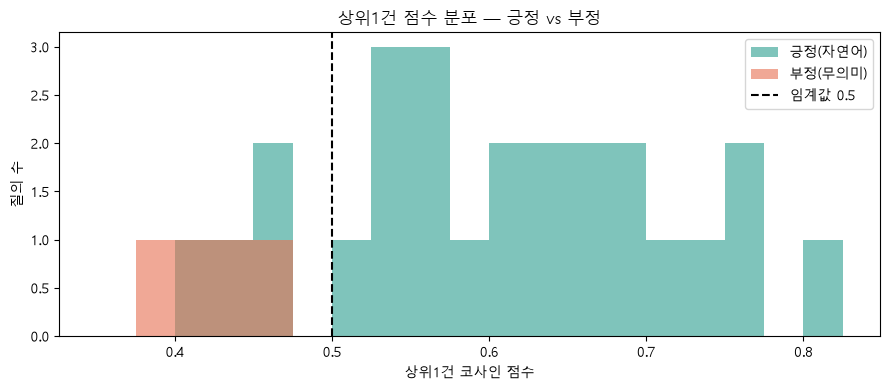

긍정 최저 0.403 / 부정 최고 0.458  → 간격 -0.055


In [7]:
pos_scores = df['score'].to_numpy()
neg_scores = neg_df['score'].to_numpy()

fig, ax = plt.subplots(figsize=(9, 4))
bins = np.arange(0.35, 0.85, 0.025)
ax.hist(pos_scores, bins=bins, alpha=0.6, label='긍정(자연어)', color='#2a9d8f')
ax.hist(neg_scores, bins=bins, alpha=0.6, label='부정(무의미)', color='#e76f51')
ax.axvline(TH, color='black', linestyle='--', label=f'임계값 {TH}')
ax.set_xlabel('상위1건 코사인 점수'); ax.set_ylabel('질의 수')
ax.set_title('상위1건 점수 분포 — 긍정 vs 부정')
ax.legend(); fig.tight_layout(); plt.show()

print(f'긍정 최저 {pos_scores.min():.3f} / 부정 최고 {neg_scores.max():.3f}'
      f'  → 간격 {pos_scores.min() - neg_scores.max():+.3f}')

## 5. 임계값 스윕 — 어디를 잘라야 하나

임계값을 0.40~0.60으로 움직이며 **긍정 채택률(재현율)** 과 **부정 오채택(헛매칭)** 을 함께 본다. 둘은 상충한다.

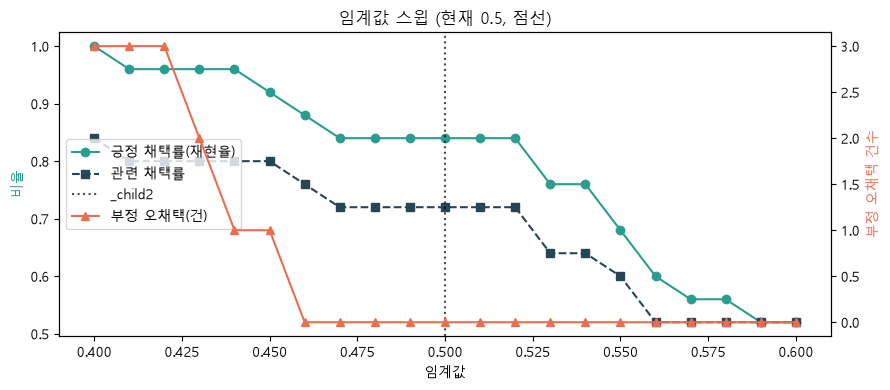

,임계값,긍정채택률,관련채택률,부정오채택
0,0.40,1.00,0.84,3
1,0.41,0.96,0.80,3
2,0.42,0.96,0.80,3
3,0.43,0.96,0.80,2
4,0.44,0.96,0.80,1
5,0.45,0.92,0.80,1
6,0.46,0.88,0.76,0
7,0.47,0.84,0.72,0
8,0.48,0.84,0.72,0
9,0.49,0.84,0.72,0


In [8]:
ths = np.round(np.arange(0.40, 0.601, 0.01), 2)
sweep = []
for t in ths:
    pos_accept = float(np.mean(pos_scores >= t))          # 긍정 채택률(재현율)
    pos_correct = float(np.mean((df['score'] >= t) & df['관련']))  # 채택 & 관련
    neg_accept = int(np.sum(neg_scores >= t))             # 부정 오채택 건수
    sweep.append({'임계값': t, '긍정채택률': round(pos_accept, 2),
                  '관련채택률': round(pos_correct, 2), '부정오채택': neg_accept})
sweep_df = pd.DataFrame(sweep)

fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.plot(sweep_df['임계값'], sweep_df['긍정채택률'], 'o-', color='#2a9d8f', label='긍정 채택률(재현율)')
ax1.plot(sweep_df['임계값'], sweep_df['관련채택률'], 's--', color='#264653', label='관련 채택률')
ax1.set_xlabel('임계값'); ax1.set_ylabel('비율', color='#2a9d8f')
ax1.axvline(TH, color='black', linestyle=':', alpha=0.7)
ax2 = ax1.twinx()
ax2.plot(sweep_df['임계값'], sweep_df['부정오채택'], '^-', color='#e76f51', label='부정 오채택(건)')
ax2.set_ylabel('부정 오채택 건수', color='#e76f51')
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [l.get_label() for l in lines], loc='center left')
ax1.set_title(f'임계값 스윕 (현재 {TH}, 점선)')
fig.tight_layout(); plt.show()
sweep_df

## 6. 신뢰도 구간 — 점수 밴드별 분포

"실제로 쓸만하려면 몇 점?"에 답한다. **0.8은 이 모델에선 거의 도달하지 않는다** — 관련 문장도 보통 0.5~0.7에 뭉친다.
구간별로 긍정 질의가 몇 개 떨어지는지 보면 임계값의 현실적 상한이 보인다.

In [9]:
bands = [
    (0.70, 1.01, '0.70↑  강한 확신'),
    (0.60, 0.70, '0.60–0.70  확실'),
    (0.50, 0.60, '0.50–0.60  경계(현재 임계값 구간)'),
    (0.46, 0.50, '0.46–0.50  노이즈와 겹침'),
    (0.00, 0.46, '0.46↓  사실상 노이즈'),
]
tier_rows = []
for lo, hi, name in bands:
    mask = (pos_scores >= lo) & (pos_scores < hi)
    예시 = ', '.join(df.loc[mask, '질의'].tolist())
    tier_rows.append({'구간': name, '긍정 질의 수': int(mask.sum()),
                      '누적 채택률': round(float(np.mean(pos_scores >= lo)), 2),
                      '예시': (예시[:45] + '…') if len(예시) > 46 else 예시})
tier_df = pd.DataFrame(tier_rows)
print(f'긍정 상위1건 점수 — 최소 {pos_scores.min():.3f} / 중앙값 {np.median(pos_scores):.3f} / 최대 {pos_scores.max():.3f}')
print(f'0.80 이상 = {int(np.sum(pos_scores >= 0.80))}개, 0.70 이상 = {int(np.sum(pos_scores >= 0.70))}개')
tier_df

긍정 상위1건 점수 — 최소 0.403 / 중앙값 0.601 / 최대 0.811
0.80 이상 = 1개, 0.70 이상 = 5개


,구간,긍정 질의 수,누적 채택률,예시
0,0.70↑ 강한 확신,5,0.20,"화장품 사려고, 아기 장난감, 등산복 아웃도어, 엘리베이터 어디, 스타벅스"
1,0.60–0.70 확실,8,0.52,"디저트랑 케이크, 립스틱 어디, 신발 파는 데, 남자 정장, 명품 매장, 그릇이나…"
2,0.50–0.60 경계(현재 임계값 구간),8,0.84,"밥 먹을 곳, 김밥 같은 분식, 커피 마시고 싶어, 향수 보고 싶어, 애들 옷, …"
3,0.46–0.50 노이즈와 겹침,1,0.88,현금 뽑을 데
4,0.46↓ 사실상 노이즈,3,1.00,"배고픈데 뭐 먹지, 가방 보러 왔어, 에스컬레이터"


## 7. 마진 분석 (top1 - top2) — 절대 점수의 대안

절대 점수 하나로는 긍정·부정이 겹친다. 대안은 **1등과 2등의 격차(margin)**: 확실한 승자가 있으면 격차가 크고,
아무거나 비슷하게 걸리는 노이즈는 격차가 작다. 예: `에스컬레이터`는 top1≈top2로 격차가 거의 0(확신할 승자 없음).

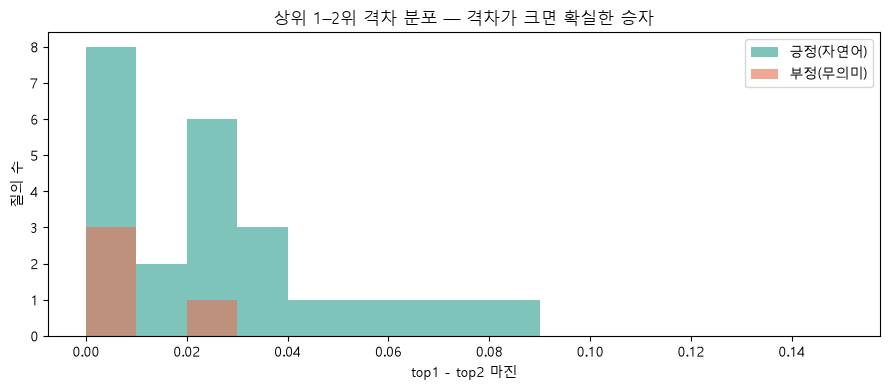

긍정 마진 중앙값 0.021 / 부정 마진 중앙값 0.004


In [10]:
def top1_and_margin(query):
    r = search(query, k=2)
    return r[0][0], r[0][0] - r[1][0]

pos_margin = np.array([top1_and_margin(q)[1] for _l, q, _e in POSITIVES])
neg_margin = np.array([top1_and_margin(q)[1] for q in NEGATIVES])

fig, ax = plt.subplots(figsize=(9, 4))
mbins = np.arange(0, 0.16, 0.01)
ax.hist(pos_margin, bins=mbins, alpha=0.6, label='긍정(자연어)', color='#2a9d8f')
ax.hist(neg_margin, bins=mbins, alpha=0.6, label='부정(무의미)', color='#e76f51')
ax.set_xlabel('top1 - top2 마진'); ax.set_ylabel('질의 수')
ax.set_title('상위 1–2위 격차 분포 — 격차가 크면 확실한 승자')
ax.legend(); fig.tight_layout(); plt.show()

print(f'긍정 마진 중앙값 {np.median(pos_margin):.3f} / 부정 마진 중앙값 {np.median(neg_margin):.3f}')

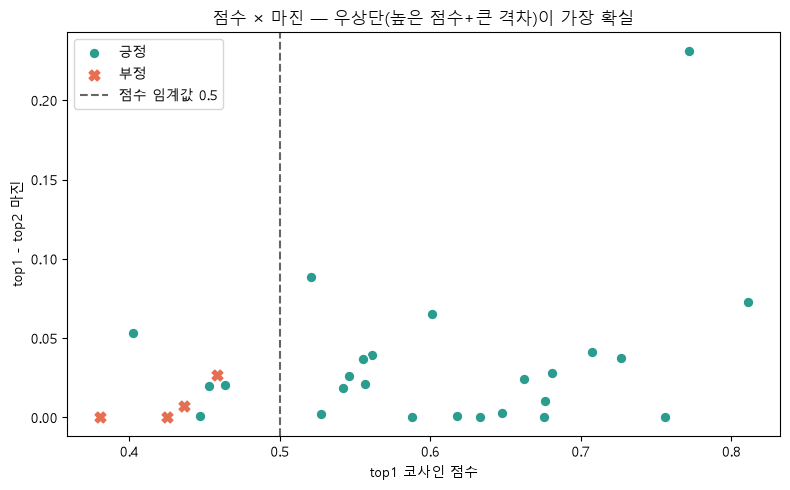

In [11]:
# 절대점수 vs 마진 — 각 질의를 (score, margin) 평면에 찍어 두 신호를 함께 본다.
pos_pairs = np.array([top1_and_margin(q) for _l, q, _e in POSITIVES])
neg_pairs = np.array([top1_and_margin(q) for q in NEGATIVES])

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(pos_pairs[:, 0], pos_pairs[:, 1], c='#2a9d8f', label='긍정', s=60, edgecolor='white')
ax.scatter(neg_pairs[:, 0], neg_pairs[:, 1], c='#e76f51', label='부정', s=60, marker='X')
ax.axvline(TH, color='black', linestyle='--', alpha=0.6, label=f'점수 임계값 {TH}')
ax.set_xlabel('top1 코사인 점수'); ax.set_ylabel('top1 - top2 마진')
ax.set_title('점수 × 마진 — 우상단(높은 점수+큰 격차)이 가장 확실')
ax.legend(); fig.tight_layout(); plt.show()

## 8. 상세 — 궁금한 질의의 상위 3건

아무 질의나 넣어 눈으로 확인. 임계값 튜닝·데이터 공백(예: 에스컬레이터) 진단용.

In [12]:
def inspect(query, k=5):
    out = search(query, k=k)
    return pd.DataFrame(
        [{'score': round(s, 3), 'top': nm, '카테고리': f'{c}/{sc}', '층': fl,
          f'채택(≥{TH})': s >= TH} for s, nm, c, sc, fl in out]
    )

inspect('현금 뽑을 데')

,score,top,카테고리,층,채택(≥0.5)
0,0.464,ATM (하나은행),편의시설/facility,6F,False
1,0.444,상품권(서비스 라운지 안),편의시설/facility,6F,False
2,0.437,물품 보관함,편의시설/facility,B1,False
3,0.413,물품보관함,편의시설/락커,B1,False
4,0.399,교환 / 환불 데스크,서비스/고객서비스,B1,False


In [13]:
session.close()
print('세션 종료')

세션 종료
